In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,141 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126284 files and dire

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

In [11]:
import pandas as pd
import seaborn as sns

# 한글 깨짐 방지 (Colab 한정)
#plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['font.family'] = 'NanumBarunGothic'  # Colab

# 1. 데이터 불러오기
train = pd.read_csv("train.csv")

# 2. 날짜 타입으로 변환
train['영업일자'] = pd.to_datetime(train['영업일자'])

# 3. '영업장명_메뉴명' 분리
train[['영업장명', '메뉴명']] = train['영업장명_메뉴명'].str.split('_', n=1, expand=True)

# 4. 파생 변수 생성
train['요일'] = train['영업일자'].dt.dayofweek  # 0=월, 6=일
train['월'] = train['영업일자'].dt.month
train['주말여부'] = train['요일'].apply(lambda x: 1 if x >= 5 else 0)

# 변수 수정
# 음수 매출수량 제거
train = train[train['매출수량'] >= 0].copy()

# 확인
train.tail(50)

,영업일자,영업장명_메뉴명,매출수량,영업장명,메뉴명,요일,월,주말여부
102626,2024-04-27,화담숲카페_현미뻥스크림,126,화담숲카페,현미뻥스크림,5,4,1
102627,2024-04-28,화담숲카페_현미뻥스크림,159,화담숲카페,현미뻥스크림,6,4,1
102628,2024-04-29,화담숲카페_현미뻥스크림,0,화담숲카페,현미뻥스크림,0,4,0
102629,2024-04-30,화담숲카페_현미뻥스크림,46,화담숲카페,현미뻥스크림,1,4,0
102630,2024-05-01,화담숲카페_현미뻥스크림,88,화담숲카페,현미뻥스크림,2,5,0
102631,2024-05-02,화담숲카페_현미뻥스크림,18,화담숲카페,현미뻥스크림,3,5,0
102632,2024-05-03,화담숲카페_현미뻥스크림,41,화담숲카페,현미뻥스크림,4,5,0
102633,2024-05-04,화담숲카페_현미뻥스크림,103,화담숲카페,현미뻥스크림,5,5,1
102634,2024-05-05,화담숲카페_현미뻥스크림,24,화담숲카페,현미뻥스크림,6,5,1
102635,2024-05-06,화담숲카페_현미뻥스크림,6,화담숲카페,현미뻥스크림,0,5,0


In [12]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 102662 entries, 0 to 102675
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   영업일자      102662 non-null  datetime64[ns]
 1   영업장명_메뉴명  102662 non-null  object        
 2   매출수량      102662 non-null  int64         
 3   영업장명      102662 non-null  object        
 4   메뉴명       102662 non-null  object        
 5   요일        102662 non-null  int32         
 6   월         102662 non-null  int32         
 7   주말여부      102662 non-null  int64         
dtypes: datetime64[ns](1), int32(2), int64(2), object(3)
memory usage: 6.3+ MB
None


In [13]:
print((train['매출수량'] < 0).sum())
print(train['매출수량'].describe())

0
count    102662.000000
mean         10.656134
std          41.889051
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max        1372.000000
Name: 매출수량, dtype: float64


| 지표         | 값       | 해석                             |
| ---------- | ------- | ------------------------------ |
| **min**    | `-80`   | ❗ **음수 매출 존재 → 비정상 데이터 (이상치)** |
| **max**    | `1372`  | 상위 극단값 존재 (정상일 수도 있음)          |
| **median** | `0`     | 전체의 절반 이상이 **판매량 0**           |
| **mean**   | `10.65` | 평균은 있지만 왜곡 가능성 높음              |
| **std**    | `41.88` | 표준편차 큼 → 데이터 분산 심함             |
| **75%**    | `4`     | 75% 구간까지도 매출 4 이하              |


In [14]:
# 음수 매출 데이터를 가진 행만 필터링
negative_sales = train[train['매출수량'] < 0]

# 확인
print(f"음수 매출수량을 가진 행 수: {len(negative_sales)}")
display(negative_sales)

음수 매출수량을 가진 행 수: 0


,영업일자,영업장명_메뉴명,매출수량,영업장명,메뉴명,요일,월,주말여부


In [9]:
print((train['매출수량'] == 0).sum())

54034


In [15]:
menu_total = train.groupby("영업장명_메뉴명").size()
menu_zeros = train[train["매출수량"] == 0].groupby("영업장명_메뉴명").size()

zero_ratio_by_menu = (menu_zeros / menu_total).fillna(0).sort_values(ascending=False)

# 상위 10개 출력
print(zero_ratio_by_menu.head(10))

영업장명_메뉴명
담하_(단체) 생목살 김치전골 2.0    0.866541
담하_문막 복분자 칵테일           0.853383
담하_명인안동소주               0.853383
담하_(단체) 은이버섯 갈비탕        0.842105
라그로타_모둠 해산물 플래터         0.842105
미라시아_공깃밥                0.836466
카페테리아_진사골 설렁탕           0.832707
담하_(단체) 공깃밥             0.825188
미라시아_잭 애플 토닉            0.813910
연회장_마라샹궈                0.802632
dtype: float64


In [16]:
# 80% 이상인 메뉴 필터링
to_remove = zero_ratio_by_menu[zero_ratio_by_menu >= 0.8].index
print(f"0 비율이 80% 이상인 메뉴 수: {len(to_remove)}")

0 비율이 80% 이상인 메뉴 수: 10


In [17]:
# 원본 train에서 해당 메뉴 제외
train = train[~train["영업장명_메뉴명"].isin(to_remove)].copy()

In [18]:
print("제거 후 전체 샘플 수:", len(train))
print("제거 후 매출 0 샘플 수:", (train["매출수량"] == 0).sum())
print("0 비율:", (train["매출수량"] == 0).mean())

제거 후 전체 샘플 수: 97342
제거 후 매출 0 샘플 수: 49582
0 비율: 0.5093587557272298


In [19]:
# 1. 매출 0인 샘플과 0이 아닌 샘플 분리
zero_df = train[train['매출수량'] == 0]
nonzero_df = train[train['매출수량'] > 0]

print(f"0 매출 샘플 수: {len(zero_df)}")
print(f"비-0 매출 샘플 수: {len(nonzero_df)}")


0 매출 샘플 수: 49582
비-0 매출 샘플 수: 47760


In [20]:
# 2. 매출 0 샘플 중 일부만 사용 (예: 30%)
zero_frac = 0.3  # 비율 조절 가능
sampled_zero_df = zero_df.sample(frac=zero_frac, random_state=42)

print(f"샘플링한 0 샘플 수: {len(sampled_zero_df)}")


샘플링한 0 샘플 수: 14875


In [21]:
# 3. 다시 합치기
train_downsampled = pd.concat([nonzero_df, sampled_zero_df]).sort_values("영업일자").reset_index(drop=True)

print(f"Downsampling 이후 전체 샘플 수: {len(train_downsampled)}")
print(f"Downsampling 이후 0 매출 비율: {(train_downsampled['매출수량'] == 0).mean():.2%}")


Downsampling 이후 전체 샘플 수: 62635
Downsampling 이후 0 매출 비율: 23.75%


In [24]:
train_downsampled.to_csv("train_downsampled.csv", index=False)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

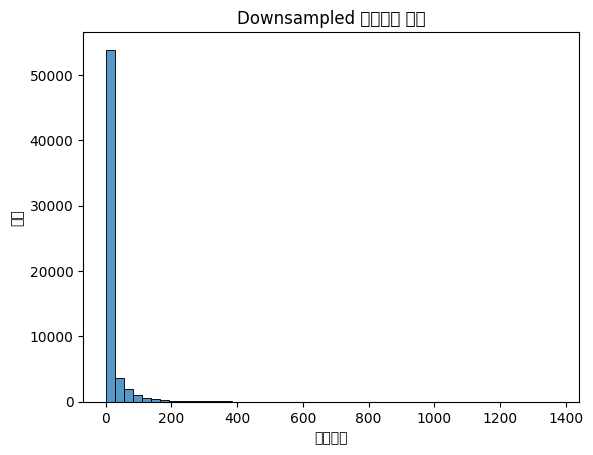

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic'  # Colab

sns.histplot(train_downsampled['매출수량'], bins=50)
plt.title("Downsampled 매출수량 분포")
plt.xlabel("매출수량")
plt.ylabel("빈도")
plt.show()


In [25]:
def create_time_features(df, lag_days=[1, 7], rolling_windows=[7]):
    """
    df: DataFrame (train_downsampled 기준)
    lag_days: 생성할 lag 일수 리스트
    rolling_windows: rolling mean 계산할 기간 리스트
    """

    df = df.sort_values(['영업장명_메뉴명', '영업일자']).copy()

    for lag in lag_days:
        df[f'lag_{lag}'] = df.groupby('영업장명_메뉴명')['매출수량'].shift(lag)
        df[f'diff_{lag}'] = df[f'lag_{lag}'] - df.groupby('영업장명_메뉴명')['매출수량'].shift(lag + 1)

    for window in rolling_windows:
        df[f'rolling_{window}_mean'] = (
            df.groupby('영업장명_메뉴명')['매출수량']
            .shift(1)  # 현재 값 포함 X
            .rolling(window, min_periods=1)
            .mean()
            .reset_index(0, drop=True)
        )

    return df

In [26]:
# 예: lag_1, lag_7 / rolling 7일 평균 생성
train_fe = create_time_features(train_downsampled,
                                lag_days=[1, 7],
                                rolling_windows=[7])

In [27]:
train_fe = train_fe.dropna().reset_index(drop=True)

In [28]:
train_fe.head(5)

,영업일자,영업장명_메뉴명,매출수량,영업장명,메뉴명,요일,월,주말여부,lag_1,diff_1,lag_7,diff_7,rolling_7_mean
0,2023-01-23,느티나무 셀프BBQ_1인 수저세트,4,느티나무 셀프BBQ,1인 수저세트,0,1,0,8.0,8.0,0.0,0.0,0.000000
1,2023-01-24,느티나무 셀프BBQ_1인 수저세트,2,느티나무 셀프BBQ,1인 수저세트,1,1,0,4.0,-4.0,0.0,0.0,3.571429
2,2023-01-27,느티나무 셀프BBQ_1인 수저세트,8,느티나무 셀프BBQ,1인 수저세트,4,1,0,2.0,-2.0,0.0,0.0,1.142857
3,2023-01-28,느티나무 셀프BBQ_1인 수저세트,0,느티나무 셀프BBQ,1인 수저세트,5,1,1,8.0,6.0,0.0,0.0,0.285714
4,2023-01-29,느티나무 셀프BBQ_1인 수저세트,8,느티나무 셀프BBQ,1인 수저세트,6,1,1,0.0,-8.0,0.0,0.0,0.333333


In [29]:
# 담하 / 미라시아 업장 데이터만 추출
target_places = ['담하', '미라시아']
filtered = train[train['영업장명'].isin(target_places)]

# 확인
filtered['영업장명'].value_counts()

,count
영업장명,
담하,19684
미라시아,15426


전체 파이프라인 순서

LightGBM 모델을 메인으로 학습

train_fe 사용

feature importance로 분석

LightGBM 성능 낮은 메뉴군 → Prophet 등으로 별도 처리

또는 앙상블 구조로 soft voting

→ 제출 시에는 모든 결과를 하나의 submission.csv로 정리

LightGBM 학습 & 예측

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserW

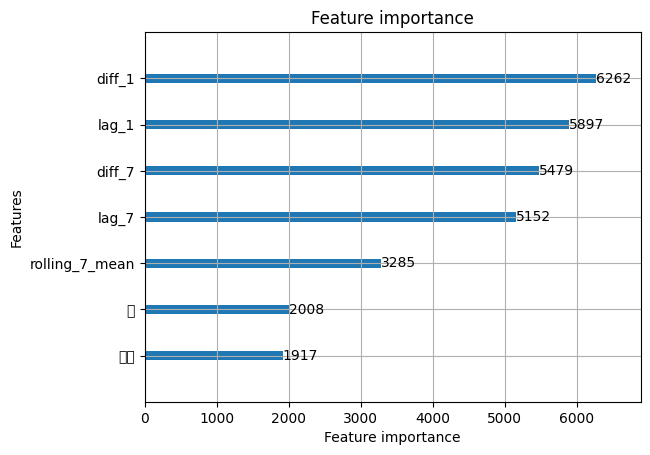

In [37]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np
plt.rcParams['font.family'] = 'NanumBarunGothic'  # Colab

# 1. 학습 대상 feature/target
features = ['요일', '월', '주말여부', 'lag_1', 'lag_7', 'diff_1', 'diff_7', 'rolling_7_mean']
target = '매출수량'

# 2. train/val split (random이 아니라 날짜 기반으로 나눠도 OK)
X_train, X_val, y_train, y_val = train_test_split(train_fe[features], train_fe[target], test_size=0.2, random_state=42)

# 3. LGBM Dataset 구성
lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

# 4. 하이퍼파라미터
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'verbosity': -1,
    'seed': 42
}

# 5. 모델 학습
model = lgb.train(params,
                  lgb_train,
                  num_boost_round=1000,
                  valid_sets=[lgb_train, lgb_val]
                  #early_stopping_rounds=50, # early_stopping_rounds는 lgb.train이 아닌 fit() 메서드에서 사용됩니다.
                  #verbose_eval=100) # verbose_eval도 lgb.train() 함수에서 직접 사용되지 않습니다.
                 )

# 6. feature importance 확인
lgb.plot_importance(model, max_num_features=15)

LightGBM으로 test 예측 수행

In [40]:
import glob
import pandas as pd
from tqdm import tqdm

# 테스트 결과 저장
lgb_preds = []

# 테스트 셋 불러오기
test_files = sorted(glob.glob("test/TEST_*.csv"))

for path in tqdm(test_files):
    test_df = pd.read_csv(path, parse_dates=['영업일자'])
    test_df[['영업장명', '메뉴명']] = test_df['영업장명_메뉴명'].str.split('_', n=1, expand=True)

    # 동일한 feature 생성 과정
    test_df = create_time_features(test_df,
                                   lag_days=[1, 7],
                                   rolling_windows=[7])
    test_df['요일'] = test_df['영업일자'].dt.dayofweek
    test_df['월'] = test_df['영업일자'].dt.month
    test_df['주말여부'] = test_df['요일'].apply(lambda x: 1 if x >= 5 else 0)

    test_df = test_df.dropna().reset_index(drop=True)
    test_df['pred'] = model.predict(test_df[features])
    test_df['pred'] = np.clip(test_df['pred'], 0, None)  # 음수 방지

    # 7일 예측만 추출
    menu_keys = test_df['영업장명_메뉴명'].unique()
    for menu in menu_keys:
        sub_df = test_df[test_df['영업장명_메뉴명'] == menu]
        last_7 = sub_df.sort_values('영업일자')['pred'][-7:].round().astype(int).tolist()
        test_id = path.split('/')[-1].replace('.csv', '') + '_' + menu
        lgb_preds.append([test_id, ','.join(map(str, last_7))])

# DataFrame으로 변환
lgb_df = pd.DataFrame(lgb_preds, columns=['id', 'sales'])

100%|██████████| 10/10 [00:07<00:00,  1.36it/s]


In [41]:
lgb_df.head()  # 예측 결과 확인
lgb_df.to_csv("lightgbm_submission.csv", index=False)

In [44]:
import pandas as pd

# 1. LightGBM 결과 불러오기
lgb_df = pd.read_csv("lightgbm_submission.csv")

# 2. ID에서 테스트셋 번호와 메뉴명 추출
lgb_df[['test_id', 'menu']] = lgb_df['id'].str.extract(r'(TEST_\d+)_([^,]+)')

# 3. sales 컬럼을 리스트로 변환
lgb_df['sales'] = lgb_df['sales'].apply(lambda x: list(map(int, x.split(','))))

# 4. sales 리스트를 7행으로 펼치기
expanded = lgb_df.explode('sales')

# 5. 영업일자 부여 (TEST_00+1일 ~ TEST_00+7일)
expanded['day_offset'] = expanded.groupby('id').cumcount()
expanded['영업일자'] = expanded['test_id'] + '+' + (expanded['day_offset'] + 1).astype(str) + '일'

# 6. 피벗 (row: 영업일자, col: 메뉴, val: sales)
pivot_df = expanded.pivot(index='영업일자', columns='menu', values='sales').reset_index()

# 7. sample_submission 순서에 맞게 열 정렬
sample = pd.read_csv("/content/sample_submission.csv")
final_df = pd.DataFrame(columns=sample.columns)
final_df['영업일자'] = pivot_df['영업일자']
for col in sample.columns[1:]:
    if col in pivot_df.columns:
        final_df[col] = pivot_df[col]
    else:
        final_df[col] = 0  # 없는 경우는 0으로 채움

# 8. 최종 제출 파일 저장
final_df.to_csv("lightgbm_submission1.csv", index=False)